In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import json
from tensorflow.keras.applications.inception_v3 import preprocess_input as incp_preprocess
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input as eff_preprocess
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input as mob_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as dense_preprocess
from tensorflow.keras.preprocessing import image

2026-02-02 21:48:36.879024: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-02 21:48:37.449636: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-02 21:48:40.309968: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
inception_model_path = './models/classification/final_inception_healthy_model2.keras'
mobilenet_model_path = './models/classification/final_mobilenet_healthy_model2.keras'
seg_model_path = './models/segmentation/best_segmentation_model.keras'
efficientnet_model_path = './models/classification/final_efficientnetb3_healthy_model.keras'
densenet_model_path = './models/classification/final_densenet_binary_healthy_model.keras'

In [3]:
@tf.keras.utils.register_keras_serializable()
def dice_coefficient(y_true, y_pred, smooth= 1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    interaction = K.sum(y_true_f * y_pred_f)
    return (2 * interaction + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

In [27]:
inception_model = tf.keras.models.load_model(inception_model_path)
segment_model = tf.keras.models.load_model(seg_model_path, custom_objects={'dice_coefficient': dice_coefficient})

In [119]:
index_mapping_path = './data/index_mapping.json'
with open(index_mapping_path, 'r') as f:
    index_mapping = json.load(f)

In [120]:
source_path = './data/'
pic = 'normal.jpg'
image_size1 = (224, 224)
image_size2 = (256, 256)
pic_path = os.path.join(source_path, pic)
mob_img = image.load_img(pic_path, target_size= image_size1)
img = image.load_img(pic_path, target_size= image_size2)
mob_img = image.img_to_array(mob_img)
img = image.img_to_array(img)
mob_img = tf.expand_dims(mob_img, axis= 0)
img = tf.expand_dims(img, axis= 0)
mob_image = mob_preprocess(mob_img)
incp_image = incp_preprocess(img)
eff_image = eff_preprocess(img)

FileNotFoundError: [Errno 2] No such file or directory: './data/normal.jpg'

In [14]:
mask_size = (256, 256)
mask_image = image.load_img(pic_path, target_size= mask_size)
mask_image = image.img_to_array(mask_image) / 255.0
mask_image = tf.expand_dims(mask_image, axis= 0)

AttributeError: 'tensorflow.python.framework.ops.EagerTensor' object has no attribute 'load_img'

In [15]:
pred_mask = segment_model(mask_image)

In [16]:
print("Pred mask stats:", tf.reduce_min(pred_mask).numpy(), tf.reduce_max(pred_mask).numpy())

Pred mask stats: 3.1436947e-08 0.9999999


In [17]:
pred_mask = tf.cast(pred_mask > 0.5, tf.uint8)
pred_mask = tf.squeeze(pred_mask)

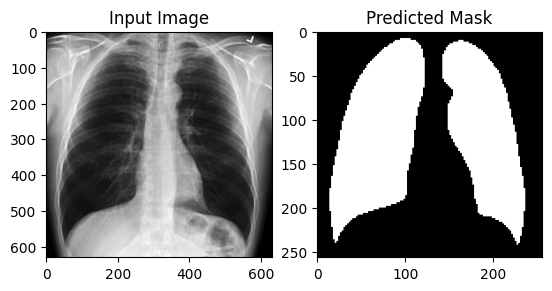

In [18]:
import matplotlib.pyplot as plt

plt.subplot(1,2,1)
plt.imshow(tf.keras.utils.load_img(pic_path))
plt.title("Input Image")

plt.subplot(1,2,2)
plt.imshow(pred_mask, cmap='gray')
plt.title("Predicted Mask")
plt.show()

In [130]:
segment_model.input_shape

(None, 256, 256, 3)

In [97]:
pred_incp = inception_model.predict(incp_image)
pred_incp = tf.argmax(pred_incp, axis= -1)
pred_incp = pred_incp.numpy()[0]
result_incp = index_mapping[str(pred_incp)]
pred_mob = mobilenet_model.predict(mob_img)
pred_mob = tf.argmax(pred_mob, axis= -1)
pred_mob = pred_mob.numpy()[0]
result_mob = index_mapping[str(pred_mob)]
pred_eff = efficientnet_model.predict(img)
pred_eff = tf.argmax(pred_eff, axis= -1)
pred_eff= pred_eff.numpy()[0]
result_eff = index_mapping[str(pred_eff)]
print(f'the {pic} result: {result_incp}, {result_mob}, {result_eff}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
the normal2.jpeg result: COVID, COVID, COVID


In [98]:
pred_mob = mobilenet_model.predict(mob_image)
print(pred_mob)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
[[9.0254289e-01 9.7192042e-02 1.5804144e-08 2.6514256e-04]]


In [99]:
pred_incp = inception_model.predict(incp_image)
print(pred_incp)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step
[[9.0270495e-01 9.7124405e-02 3.1691448e-11 1.7071892e-04]]


In [100]:
pred_eff = efficientnet_model.predict(eff_image)
print(pred_eff)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
[[9.4430929e-01 5.5631924e-02 2.3245525e-08 5.8754726e-05]]


In [93]:
class_mapping_path = './data/class_mapping.json'
with open(class_mapping_path, 'r') as f:
    cm = json.load(f)

In [94]:
cm

{'COVID': 0, 'Normal': 1, 'Viral Pneumonia': 2, 'Lung_Opacity': 3}

In [26]:
index_mapping = {index: class_name for class_name, index in cm.items()}

In [28]:
index_mapping_path = './data/index_mapping.json'
with open(index_mapping_path, 'w') as f:
    json.dump(index_mapping, f, indent= 4)

In [29]:
index_mapping_path = './data/index_mapping.json'
with open(index_mapping_path, 'r') as f:
    im = json.load(f)

In [1059]:
source_path = './data/test_images/'
pic = 'lo1.jpeg'
image_size2 = (256, 256)
pic_path = os.path.join(source_path, pic)

In [1060]:
img_pil = image.load_img(pic_path, target_size=image_size2)
img_array = image.img_to_array(img_pil)
img_for_masking = tf.expand_dims(img_array, axis=0)

In [1061]:
mask_size = (256, 256)
seg_input = img_for_masking / 255.0
pred_mask_raw = segment_model.predict(seg_input)
pred_mask_binary = tf.cast(pred_mask_raw > 0.5, tf.float32)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step


In [1062]:
pred_mask_3ch = tf.image.grayscale_to_rgb(pred_mask_binary[0]) # From (H, W, 1) to (H, W, 3)
pred_mask_3ch = tf.expand_dims(pred_mask_3ch, axis=0)

In [1063]:
img_pre = incp_preprocess(img_for_masking)
lung_part = img_pre * pred_mask_3ch
background_part = (1.0 - pred_mask_3ch) * -1.0
masked_img = lung_part + background_part

In [1064]:
predictions = inception_model.predict(masked_img)
print(predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
[[0.77961504]]


In [27]:
SOURCE_PATH = './data/test_images/'
MASK_SIZE = (256, 256)
IMAGE_SIZE = (256, 256)
test_files = glob.glob(os.path.join(SOURCE_PATH, '*.jpeg'))
test_files.extend(glob.glob(os.path.join(SOURCE_PATH, '*.png')))
test_files.extend(glob.glob(os.path.join(SOURCE_PATH, '*.jpg')))
all_preds = {}

In [28]:
model = tf.keras.models.load_model(inception_model_path)
segment_model = tf.keras.models.load_model(seg_model_path, custom_objects={'dice_coefficient': dice_coefficient})

In [29]:
def final_predict(model, x, threshold=0.5):
    prob = model.predict(x, verbose=0)[0]
    prob_s = prob.item()
    label = int(prob >= threshold)
    return prob_s, label

In [30]:
inception_preds = {}
for file_path in test_files:
    file_pred = {}
    file_name = os.path.basename(file_path)

    # 1. Load raw image [0,255]
    img_pil = image.load_img(file_path, target_size=IMAGE_SIZE)
    img_array = image.img_to_array(img_pil)
    img_array = tf.expand_dims(img_array, axis=0)

    # 2. Segmentation model (expects [0,1])
    seg_input = img_array / 255.0
    pred_mask_raw = segment_model.predict(seg_input, verbose=0)
    pred_mask_binary = tf.cast(pred_mask_raw > 0.5, tf.float32)

    # 3. Make 3-channel mask
    pred_mask_3ch = tf.image.grayscale_to_rgb(pred_mask_binary[0])
    pred_mask_3ch = tf.expand_dims(pred_mask_3ch, axis=0)

    # 4. Inception preprocessing (NOW)
    img_preprocessed = incp_preprocess(img_array)

    # 5. Apply SAME masking logic as training
    lung_part = img_preprocessed * pred_mask_3ch
    background_part = (1.0 - pred_mask_3ch) * -1.0
    img_final = lung_part + background_part

    # 6. Predict
    pred_score, pred_label = final_predict(model, img_final, threshold=0.5)
    file_pred["score"] = pred_score
    file_pred["label"] = pred_label
    inception_preds[file_name] = file_pred

    print(f"{file_name:<35}\tScore: {pred_score:.4f}\tLabel: {pred_label}")

all_preds["inception"] = inception_preds

/tmp/ipykernel_412/1765721834.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(prob >= threshold)


BCH-covid-2-days.jpeg              	Score: 0.9838	Label: 1
Chest-X-ray-normal.jpeg            	Score: 0.9790	Label: 1
covid.jpeg                         	Score: 0.5506	Label: 1
covid10jpeg.jpeg                   	Score: 0.9881	Label: 1
covid3.jpeg                        	Score: 0.4595	Label: 0
covid4.jpeg                        	Score: 0.9063	Label: 1
covid6.jpeg                        	Score: 0.9929	Label: 1
covid7.jpeg                        	Score: 0.9848	Label: 1
covid8.jpeg                        	Score: 0.9889	Label: 1
covid9.jpeg                        	Score: 0.8160	Label: 1
gr2.jpeg                           	Score: 0.9926	Label: 1
h.jpeg                             	Score: 0.1357	Label: 0
h1.jpeg                            	Score: 0.0913	Label: 0
h2.jpeg                            	Score: 0.0768	Label: 0
h3.jpeg                            	Score: 0.0353	Label: 0
h4.jpeg                            	Score: 0.0294	Label: 0
h5.jpeg                            	Score: 0.7937	Label:

In [31]:
model = tf.keras.models.load_model(mobilenet_model_path)

In [32]:
mobile_preds = {}
for file_path in test_files:
    file_pred = {}
    file_name = os.path.basename(file_path)
    
    # 1. Load image (Raw [0, 255])
    img_pil = image.load_img(file_path, target_size=IMAGE_SIZE)
    img_array = image.img_to_array(img_pil) 
    img_for_masking = tf.expand_dims(img_array, axis=0) # (1, H, W, 3)
    
    # 2. Prepare segmentation input and predict mask
    seg_input = img_for_masking / 255.0
    pred_mask_raw = segment_model.predict(seg_input, verbose=0) 
    pred_mask_binary = tf.cast(pred_mask_raw > 0.5, tf.float32)
    
    # 3. Create 3-Channel Mask for multiplication
    pred_mask_3ch = tf.image.grayscale_to_rgb(pred_mask_binary[0])
    pred_mask_3ch = tf.expand_dims(pred_mask_3ch, axis=0)

    # 4. MobileNetV3 Masking: Input [0, 255] * Mask [0, 1] -> Background is 0
    masked_img = img_for_masking * pred_mask_3ch
    
    # 5. Predict
    pred_score, pred_label = final_predict(model, masked_img, threshold=0.5)
    file_pred["score"] = pred_score
    file_pred["label"] = pred_label
    mobile_preds[file_name] = file_pred

    print(f"{file_name:<35}\tScore: {pred_score:.4f}\tLabel: {pred_label}")

all_preds["mobile"] = mobile_preds

/tmp/ipykernel_412/1765721834.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(prob >= threshold)


BCH-covid-2-days.jpeg              	Score: 0.9889	Label: 1
Chest-X-ray-normal.jpeg            	Score: 0.9751	Label: 1
covid.jpeg                         	Score: 0.6273	Label: 1
covid10jpeg.jpeg                   	Score: 0.9898	Label: 1
covid3.jpeg                        	Score: 0.7166	Label: 1
covid4.jpeg                        	Score: 0.9653	Label: 1
covid6.jpeg                        	Score: 0.9986	Label: 1
covid7.jpeg                        	Score: 0.9850	Label: 1
covid8.jpeg                        	Score: 0.9835	Label: 1
covid9.jpeg                        	Score: 0.9316	Label: 1
gr2.jpeg                           	Score: 0.9996	Label: 1
h.jpeg                             	Score: 0.3987	Label: 0
h1.jpeg                            	Score: 0.0059	Label: 0
h2.jpeg                            	Score: 0.0259	Label: 0
h3.jpeg                            	Score: 0.0116	Label: 0
h4.jpeg                            	Score: 0.0151	Label: 0
h5.jpeg                            	Score: 0.2974	Label:

In [33]:
model = tf.keras.models.load_model(efficientnet_model_path)

In [34]:
efficient_preds = {}
for file_path in test_files:
    file_pred = {}
    file_name = os.path.basename(file_path)
    
    # 1. Load image (Raw [0, 255])
    img_pil = image.load_img(file_path, target_size=IMAGE_SIZE)
    img_array = image.img_to_array(img_pil) 
    img_for_scaling = tf.expand_dims(img_array, axis=0) # (1, H, W, 3)
    
    # 2. Prepare segmentation input and predict mask
    seg_input = img_for_scaling / 255.0
    pred_mask_raw = segment_model.predict(seg_input, verbose=0) 
    
    # Mask is binary [0, 1] and remains 1-channel (1, H, W, 1)
    pred_mask_binary = tf.cast(pred_mask_raw > 0.5, tf.float32) 

    # --- NEW 4-CHANNEL PREPROCESSING ---
    
    # 3. Scale Image to [-1, 1] range (Channels 1-3)
    image_scaled = (img_for_scaling / 127.5) - 1.0
    
    # 4. Mask is already scaled [0, 1] (Channel 4)
    mask_scaled = pred_mask_binary
    
    # 5. Concatenate to create 4-channel input (1, H, W, 4)
    input_4ch = tf.concat([image_scaled, mask_scaled], axis=-1)
    
    # 6. Predict using the 4-channel input
    pred_score, pred_label = final_predict(model, input_4ch, threshold=0.85)
    file_pred["score"] = pred_score
    file_pred["label"] = pred_label
    efficient_preds[file_name] = file_pred

    print(f"{file_name:<35}\tScore: {pred_score:.4f}\tLabel: {pred_label}")

all_preds["efficient"] = efficient_preds

/tmp/ipykernel_412/1765721834.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(prob >= threshold)


BCH-covid-2-days.jpeg              	Score: 0.9632	Label: 1
Chest-X-ray-normal.jpeg            	Score: 0.9706	Label: 1
covid.jpeg                         	Score: 0.0206	Label: 0
covid10jpeg.jpeg                   	Score: 0.9625	Label: 1
covid3.jpeg                        	Score: 0.9086	Label: 1
covid4.jpeg                        	Score: 0.9783	Label: 1
covid6.jpeg                        	Score: 0.9899	Label: 1
covid7.jpeg                        	Score: 0.8833	Label: 1
covid8.jpeg                        	Score: 0.9417	Label: 1
covid9.jpeg                        	Score: 0.9682	Label: 1
gr2.jpeg                           	Score: 0.9824	Label: 1
h.jpeg                             	Score: 0.2248	Label: 0
h1.jpeg                            	Score: 0.0472	Label: 0
h2.jpeg                            	Score: 0.7723	Label: 0
h3.jpeg                            	Score: 0.0257	Label: 0
h4.jpeg                            	Score: 0.4919	Label: 0
h5.jpeg                            	Score: 0.9133	Label:

In [35]:
def lung_roi_preprocess(image, mask):
    mask = tf.squeeze(mask, axis=0)
    mask_2d = tf.cast(mask[:, :, 0], tf.float32)
    indices = tf.where(mask_2d > 0.5)
    img_shape = tf.shape(image)

    def crop():
        min_coords = tf.cast(tf.reduce_min(indices, axis=0), tf.int32)
        max_coords = tf.cast(tf.reduce_max(indices, axis=0), tf.int32)

        y_min = min_coords[0]
        x_min = min_coords[1]
        y_max = max_coords[0]
        x_max = max_coords[1]

        h = tf.cast(y_max - y_min, tf.float32)
        w = tf.cast(x_max - x_min, tf.float32)

        margin_y = tf.cast(h * 0.1, tf.int32)
        margin_x = tf.cast(w * 0.1, tf.int32)

        y_start = tf.maximum(0, y_min - margin_y)
        x_start = tf.maximum(0, x_min - margin_x)
        y_end = tf.minimum(img_shape[0], y_max + margin_y)
        x_end = tf.minimum(img_shape[1], x_max + margin_x)

        final_h = tf.maximum(y_end - y_start, 1)
        final_w = tf.maximum(x_end - x_start, 1)

        cropped = tf.image.crop_to_bounding_box(
            image, y_start, x_start, final_h, final_w
        )
        return tf.image.resize(cropped, (256, 256))

    def fallback():
        print("yoho")
        return tf.image.resize(image, (256, 256))

    image = tf.cond(tf.shape(indices)[0] > 0, crop, fallback)

    return image

In [36]:
model = tf.keras.models.load_model(densenet_model_path)

In [37]:
dense_preds = {}
for file_path in test_files:
    file_pred = {}
    file_name = os.path.basename(file_path)
    
    # 1. Load image (Raw [0, 255])
    img_pil = image.load_img(file_path, target_size=IMAGE_SIZE)
    img_array = image.img_to_array(img_pil) 
    img_for_masking = tf.expand_dims(img_array, axis=0) # (1, H, W, 3)
    
    # 2. Prepare segmentation input and predict mask
    seg_input = img_for_masking / 255.0
    pred_mask_raw = segment_model.predict(seg_input, verbose=0) 
    pred_mask_binary = tf.cast(pred_mask_raw > 0.5, tf.float32)
    
    img_roi = lung_roi_preprocess(img_pil, pred_mask_binary)
    # 4. MobileNetV3 Masking: Input [0, 255] * Mask [0, 1] -> Background is 0
    masked_img = dense_preprocess(img_roi)
    masked_img = tf.expand_dims(masked_img, axis=0)
    # 5. Predict
    
    pred_score, pred_label = final_predict(model, masked_img, threshold=0.91)
    file_pred["score"] = pred_score
    file_pred["label"] = pred_label
    dense_preds[file_name] = file_pred
    print(f"{file_name:<35}\tScore: {pred_score:.4f}\tLabel: {pred_label}")

all_preds["dense"] = dense_preds

/tmp/ipykernel_412/1765721834.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(prob >= threshold)


BCH-covid-2-days.jpeg              	Score: 0.9986	Label: 1
Chest-X-ray-normal.jpeg            	Score: 0.8725	Label: 0
covid.jpeg                         	Score: 0.8806	Label: 0
covid10jpeg.jpeg                   	Score: 0.9498	Label: 1
covid3.jpeg                        	Score: 0.9609	Label: 1
covid4.jpeg                        	Score: 0.8193	Label: 0
covid6.jpeg                        	Score: 0.9945	Label: 1
covid7.jpeg                        	Score: 0.9981	Label: 1
covid8.jpeg                        	Score: 0.9964	Label: 1
covid9.jpeg                        	Score: 0.9832	Label: 1
gr2.jpeg                           	Score: 0.9988	Label: 1
h.jpeg                             	Score: 0.8371	Label: 0
h1.jpeg                            	Score: 0.5831	Label: 0
h2.jpeg                            	Score: 0.8120	Label: 0
h3.jpeg                            	Score: 0.4493	Label: 0
h4.jpeg                            	Score: 0.1482	Label: 0
h5.jpeg                            	Score: 0.7547	Label:

In [45]:
def generate_ensemble_dict(data):
    '''
    Generates an ensemble dictionary by averaging scores and applying 
    a majority-vote (threshold 2/4) for labels.
    '''
    ensemble = {}
    model_names = list(data.keys())
    # Identify all unique image filenames
    image_names = list(data[model_names[0]].keys())
    num_models = len(model_names)

    for img in image_names:
        total_score = 0
        total_label_1 = 0
        
        for model in model_names:
            total_score += data[model][img]['score']
            if data[model][img]['label'] == 1:
                total_label_1 += 1
        
        # Calculate mean score and ensemble label
        avg_score = total_score / num_models
        # Logic: if 2 or more models say 1, ensemble label is 1
        ensemble_label = 1 if total_label_1 > 2 else 0
        
        ensemble[img] = {
            'score': avg_score,
            'label': ensemble_label
        }
    
    return ensemble


In [46]:
result = generate_ensemble_dict(all_preds)

In [47]:
result

{'BCH-covid-2-days.jpeg': {'score': 0.9836007952690125, 'label': 1},
 'Chest-X-ray-normal.jpeg': {'score': 0.9492855370044708, 'label': 1},
 'covid.jpeg': {'score': 0.5197692895308137, 'label': 1},
 'covid10jpeg.jpeg': {'score': 0.9725463539361954, 'label': 1},
 'covid3.jpeg': {'score': 0.7613954171538353, 'label': 1},
 'covid4.jpeg': {'score': 0.9173127561807632, 'label': 1},
 'covid6.jpeg': {'score': 0.9939519464969635, 'label': 1},
 'covid7.jpeg': {'score': 0.9627860933542252, 'label': 1},
 'covid8.jpeg': {'score': 0.9776116460561752, 'label': 1},
 'covid9.jpeg': {'score': 0.924731507897377, 'label': 1},
 'gr2.jpeg': {'score': 0.9933354258537292, 'label': 1},
 'h.jpeg': {'score': 0.3990934081375599, 'label': 0},
 'h1.jpeg': {'score': 0.1818661541910842, 'label': 0},
 'h2.jpeg': {'score': 0.4217458749189973, 'label': 0},
 'h3.jpeg': {'score': 0.13047642773017287, 'label': 0},
 'h4.jpeg': {'score': 0.1711369960103184, 'label': 0},
 'h5.jpeg': {'score': 0.6897587403655052, 'label': 1},

In [20]:
H,W = IMG_SIZE
black = np.zeros((H,W,3), dtype='float32')
white = np.ones((H,W,3), dtype='float32') * 255.0

# full-lung mask (all ones) and empty mask (all zeros)
full_mask3 = np.ones((H,W,3), dtype='float32')
empty_mask3 = np.zeros((H,W,3), dtype='float32')

def run_and_print(img_arr, mask3):
    inp = np.expand_dims(img_arr * mask3, 0).astype('float32')
    print("input min/max/mean:", inp.min(), inp.max(), inp.mean())
    print("model ->", model.predict(inp, verbose=0))

print("BLACK with full mask (black image but mask applied):")
run_and_print(black, full_mask3)
print("WHITE with full mask:")
run_and_print(white, full_mask3)
print("BLACK with empty mask (should be all zeros):")
run_and_print(black, empty_mask3)

NameError: name 'IMG_SIZE' is not defined

In [14]:
# using pred_mask_raw computed above
print("pred_mask_raw min/max mean:", float(pred_mask_raw.min()), float(pred_mask_raw.max()), float(pred_mask_raw.mean()))
unique_vals = np.unique(np.round(pred_mask_raw,3))
print("unique values sample (first 20):", unique_vals.flatten()[:20])

# After binarization:
print("pred_mask_bin unique:", np.unique(pred_mask_bin))
# area ratios:
mask_area = pred_mask_bin.sum()
img_area = pred_mask_bin.size
print("mask area (pixels):", int(mask_area), "mask fraction:", float(mask_area)/img_area)


pred_mask_raw min/max mean: 9.165930237031716e-09 1.0 0.1910233497619629
unique values sample (first 20): [0.    0.001 0.002 0.003 0.004 0.005 0.006 0.007 0.008 0.009 0.01  0.011
 0.012 0.013 0.014 0.015 0.016 0.017 0.018 0.019]
pred_mask_bin unique: [0. 1.]
mask area (pixels): 12540 mask fraction: 0.19134521484375


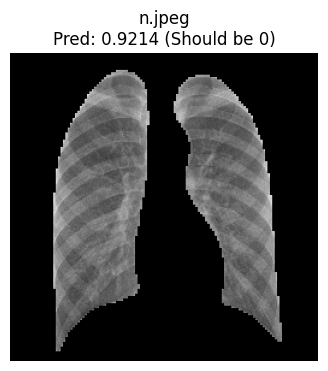

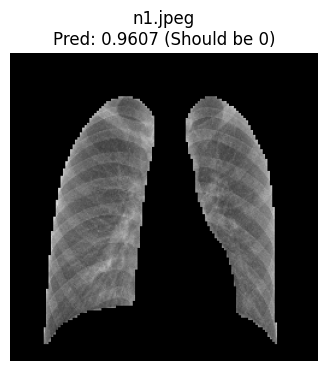

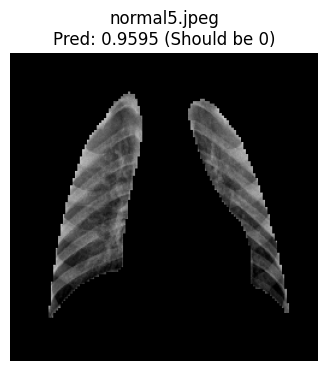

In [8]:
import matplotlib.pyplot as plt

# List of images that failed (Healthy predicted as Unhealthy)
failed_images = ['n.jpeg', 'n1.jpeg', 'normal5.jpeg'] 

for pic_name in failed_images:
    file_path = os.path.join(SOURCE_PATH, pic_name)
    
    # Load and Preprocess (Same as your loop)
    img_pil = image.load_img(file_path, target_size=IMAGE_SIZE)
    img_array = image.img_to_array(img_pil)
    img_for_masking = tf.expand_dims(img_array, axis=0)
    
    # Generate Mask
    seg_input = img_for_masking / 255.0
    pred_mask_raw = segment_model.predict(seg_input, verbose=0)
    pred_mask_binary = tf.cast(pred_mask_raw > 0.5, tf.float32)
    pred_mask_3ch = tf.image.grayscale_to_rgb(pred_mask_binary[0])
    pred_mask_3ch = tf.expand_dims(pred_mask_3ch, axis=0)
    
    # Apply Mask
    masked_img = img_for_masking * pred_mask_3ch
    
    # Predict
    pred = model.predict(masked_img, verbose=0)[0][0]
    
    # PLOT
    plt.figure(figsize=(4, 4))
    plt.imshow(masked_img[0].numpy().astype("uint8"))
    plt.title(f"{pic_name}\nPred: {pred:.4f} (Should be 0)")
    plt.axis('off')
    plt.show()

In [9]:
import tensorflow as tf
model = tf.keras.models.load_model(efficientnet_model_path)
print("Model input shape:", model.input_shape)
for i,layer in enumerate(model.layers[:30]):
    print(i, layer.name, type(layer))
# quick find rescaling
rescalers = [l for l in model.layers if 'rescaling' in l.name.lower() or 'rescale' in l.name.lower()]
print("Rescaling layers:", rescalers)


Model input shape: (None, 256, 256, 3)
0 input_layer_5 <class 'keras.src.layers.core.input_layer.InputLayer'>
1 efficientnetv2-b3 <class 'keras.src.models.functional.Functional'>
2 global_average_pooling2d_2 <class 'keras.src.layers.pooling.global_average_pooling2d.GlobalAveragePooling2D'>
3 dense_6 <class 'keras.src.layers.core.dense.Dense'>
4 dropout_4 <class 'keras.src.layers.regularization.dropout.Dropout'>
5 dense_7 <class 'keras.src.layers.core.dense.Dense'>
6 dropout_5 <class 'keras.src.layers.regularization.dropout.Dropout'>
7 dense_8 <class 'keras.src.layers.core.dense.Dense'>
Rescaling layers: []


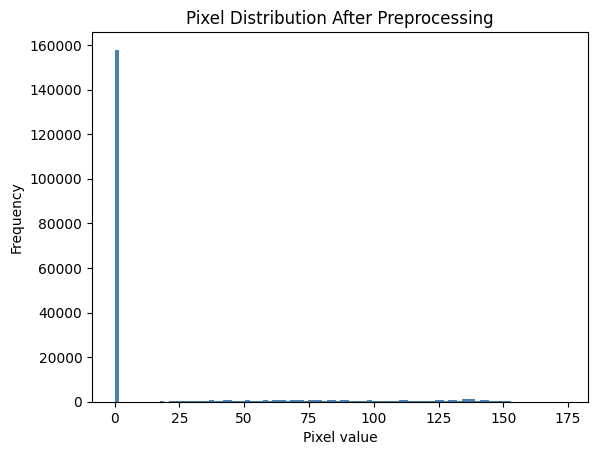

In [7]:
img = masked_img[0].numpy().flatten()
plt.hist(img, bins=100, color='steelblue')
plt.title("Pixel Distribution After Preprocessing")
plt.xlabel("Pixel value")
plt.ylabel("Frequency")
plt.show()

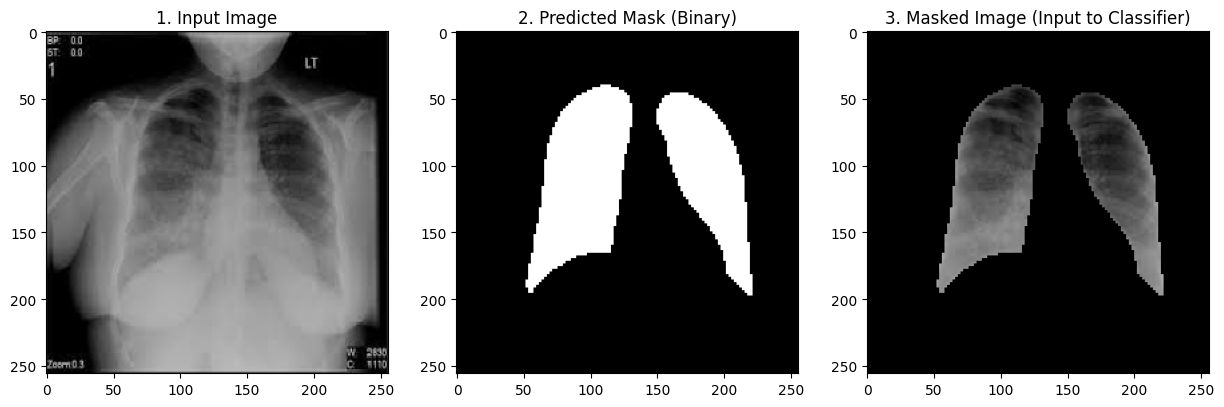

In [101]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# --- Assuming these variables are available from the previous step: ---
# img_for_masking (Original image with batch dim, [0, 255])
# pred_mask_binary (Binary mask with batch dim, [0, 1])
# masked_img (Result of element-wise multiplication, [0, 255])
# --------------------------------------------------------------------

# Squeeze the Tensors to remove the batch dimension (1, H, W, C) -> (H, W, C) for plotting
input_img_plot = tf.squeeze(img_for_masking).numpy().astype(np.uint8)
masked_img_plot = tf.squeeze(masked_img).numpy().astype(np.uint8)
pred_mask_plot = tf.squeeze(pred_mask_binary).numpy() # Binary mask [0, 1]

plt.figure(figsize=(15, 5))

# Plot 1: Original Image
plt.subplot(1, 3, 1)
plt.imshow(input_img_plot)
plt.title("1. Input Image")

# Plot 2: Predicted Mask
plt.subplot(1, 3, 2)
# Use 'gray' colormap for the single-channel binary mask
plt.imshow(pred_mask_plot, cmap='gray')
plt.title("2. Predicted Mask (Binary)")

# Plot 3: Masked Image (Input to Inception)
plt.subplot(1, 3, 3)
plt.imshow(masked_img_plot)
plt.title("3. Masked Image (Input to Classifier)")

plt.show()

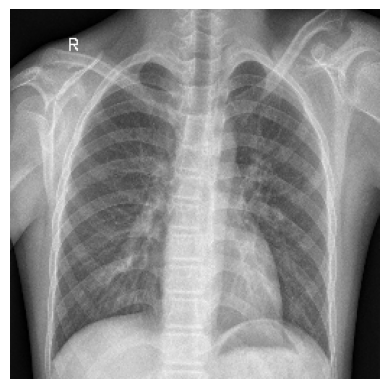

In [89]:
img = image.load_img(test_files[20], target_size=IMAGE_SIZE)
plt.axis('off')
plt.imshow(img)
plt.show()

In [90]:
img_array = image.img_to_array(img)
img_for_mask = tf.expand_dims(img_array, axis=0)

seg_in = img_for_mask / 255.0
pred_mask = segment_model.predict(seg_in)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step


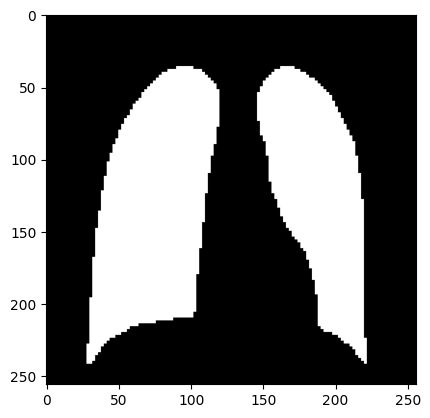

In [91]:
pred_mask = tf.cast(pred_mask > 0.5, tf.float32)
plt.imshow(tf.squeeze(pred_mask), cmap='gray')

In [92]:
pred_mask.shape

TensorShape([1, 256, 256, 1])

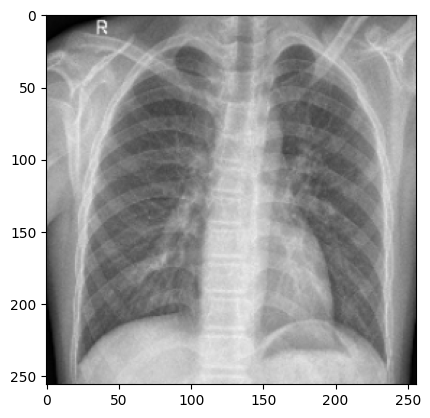

In [94]:
img_roi = lung_roi_preprocess(img, pred_mask) / 255.0
plt.imshow(img_roi)

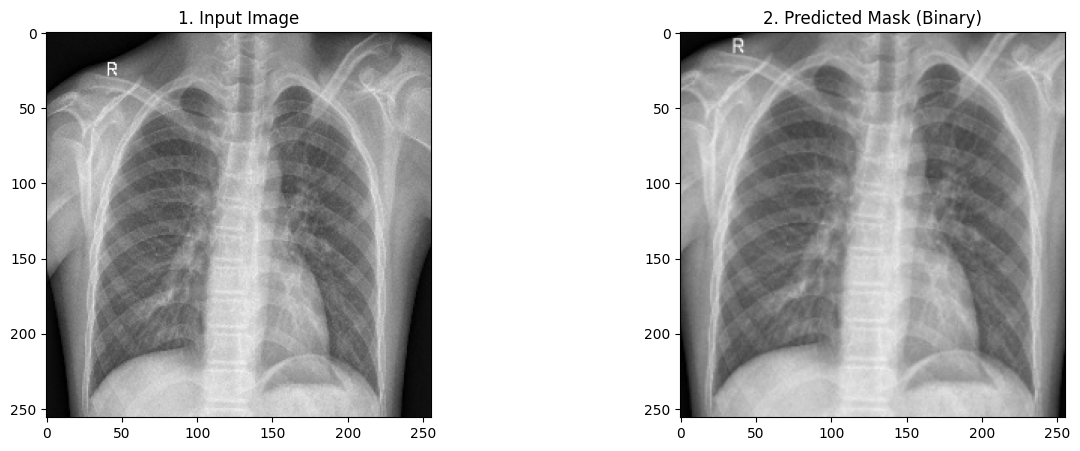

In [95]:
plt.figure(figsize=(15, 5))

# Plot 1: Original Image
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("1. Input Image")

# Plot 2: Predicted Mask
plt.subplot(1, 2, 2)
# Use 'gray' colormap for the single-channel binary mask
plt.imshow(img_roi)
plt.title("2. Predicted Mask (Binary)")

plt.show()